In [1]:
# 1. 在 Colab 新建一个 notebook（作为你的“主控台”）

# 2. 挂载 Google Drive（作为你的“数据仓库”）
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
# 3. 进入你的项目文件夹
import os
os.chdir('/content/drive/MyDrive/ll_FORUM_CLASSIFICATION-master')
# 或者直接 %cd /content/drive/MyDrive/你的项目文件夹

# 4. 现在你可以：
#    - 直接运行项目里的 .py 文件：!python train.py
#    - 或者导入自己写的模块：from my_utils import preprocess
#    - 数据也都在当前目录下，路径不用改

In [3]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.3 MB/s eta 0:00:00


In [29]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score, cohen_kappa_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from nltk import pos_tag, word_tokenize
from textblob import TextBlob

In [5]:
import nltk
import os

# 设置下载目录
download_dir = '/root/nltk_data'
os.makedirs(download_dir, exist_ok=True)

# 确保目录在搜索路径中
if download_dir not in nltk.data.path:
    nltk.data.path.append(download_dir)

# 更新后的包列表（加入了 stopwords）
packages = [
    'wordnet',
    'omw-1.4',
    'punkt',
    'punkt_tab',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'stopwords'  # 关键：加上这一行！
]

# 下载所有需要的包
for pkg in packages:
    try:
        # 根据不同包类型构造不同的查找路径
        if pkg in ['punkt', 'punkt_tab']:
            nltk.data.find(f'tokenizers/{pkg}')
        elif pkg in ['averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
            nltk.data.find(f'taggers/{pkg}')
        else:
            nltk.data.find(f'corpora/{pkg}')
        print(f"✓ {pkg} 已存在")
    except LookupError:
        print(f"↓ 正在下载 {pkg}...")
        nltk.download(pkg, download_dir=download_dir)

↓ 正在下载 wordnet...


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


↓ 正在下载 omw-1.4...
↓ 正在下载 punkt...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


↓ 正在下载 punkt_tab...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


↓ 正在下载 averaged_perceptron_tagger...
↓ 正在下载 averaged_perceptron_tagger_eng...


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


↓ 正在下载 stopwords...


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [30]:
# -------------------------------
# 1. 自定义统计特征
# -------------------------------
def text_features(texts):
    features = []
    for t in texts:
        if not isinstance(t, str):
            t = ""
        tokens = word_tokenize(t)
        length = len(tokens)
        avg_len = np.mean([len(w) for w in tokens]) if tokens else 0
        pos_counts = pos_tag(tokens)
        nouns = sum(1 for w, p in pos_counts if p.startswith("NN"))
        verbs = sum(1 for w, p in pos_counts if p.startswith("VB"))
        sentiment = TextBlob(t).sentiment.polarity
        features.append([length, avg_len, nouns, verbs, sentiment])
    return np.array(features)

extra_features = FunctionTransformer(text_features, validate=False)

# -------------------------------
# 2. TF-IDF 特征（保持原始参数）
# -------------------------------
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=3000)

# -------------------------------
# 3. 特征组合
# -------------------------------
features = FeatureUnion([
    ("tfidf", tfidf),
    ("extra", Pipeline([
        ("extract", extra_features),
        ("scale", StandardScaler())
    ]))
])

# -------------------------------
# 4. 构建 pipeline + SMOTE（保持原始参数）
# -------------------------------
pipeline = ImbPipeline([
    ("features", features),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

类别分布：
Label
0    23186
1     6418
Name: count, dtype: int64
F1 Score: 0.669010989010989
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4637
           1       0.77      0.59      0.67      1284

    accuracy                           0.87      5921
   macro avg       0.83      0.77      0.80      5921
weighted avg       0.87      0.87      0.87      5921



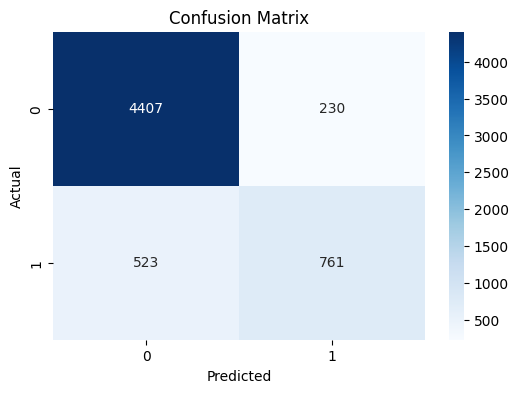

In [31]:
# -------------------------------
# 5. 训练 & 类别统计
# -------------------------------
df = pd.read_csv("data_processed.xlsx")
X = df["Text"].fillna("")
y = df["Label"]

print("类别分布：")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -------------------------------
# 6. 混淆矩阵
# -------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)

# AUC (需要概率分数)
y_proba = pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Cohen's Kappa:", kappa)
print("AUC:", auc)
print("F1 Score:", f1)

Accuracy: 0.8728255362269887
Cohen's Kappa: 0.5919125793896363
AUC: 0.9089267922850001
F1 Score: 0.669010989010989


In [33]:
import joblib

# -------------------------------
# 7. 保存模型
# -------------------------------
joblib.dump(pipeline, "RF_classifier.pkl")
print("模型已保存为 RF_classifier.pkl")

模型已保存为 RF_classifier.pkl


In [34]:
# -------------------------------
# 9. 输出前 n 个最重要特征
# -------------------------------
def get_top_features(pipeline, n=20):
    clf = pipeline.named_steps["clf"]
    coefficients = clf.coef_[0]

    # TF-IDF 特征名
    tfidf = pipeline.named_steps["features"].transformer_list[0][1]
    tfidf_features = ["tfidf_" + f for f in tfidf.get_feature_names_out()]

    # 统计特征名
    extra_features = ["extra_token_length", "extra_avg_word_len",
                      "extra_noun_count", "extra_verb_count", "extra_sentiment"]

    # 合并所有特征名
    all_features = np.concatenate([tfidf_features, extra_features])

    # 按绝对值排序
    top_idx = np.argsort(np.abs(coefficients))[-n:]
    important_features = list(zip(all_features[top_idx], coefficients[top_idx]))

    return sorted(important_features, key=lambda x: abs(x[1]), reverse=True)

# 示例：输出前20个最重要特征
top_features = get_top_features(pipeline, n=20)
print("Top 20 最重要特征：")
for feat, coef in top_features:
    print(f"{feat}: {coef:.4f}")

AttributeError: 'RandomForestClassifier' object has no attribute 'coef_'